# Final Analysis — Consolidated Results

Synthesizes evidence across GTZAN, FMA, INDIAN, TABLA.
Objectives:

- Provide a self-contained quantitative record.
- Focus on accuracy, parameter count, latency (exclude FLOPs).
- Derive micro/macro/weighted metrics from classification reports.
- Plot ROC and Precision–Recall when probabilities available.

Reports: `reports/`; models: `models/`.


In [11]:
# Setup: imports, paths, style
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from typing import Optional, Dict, List

# Metrics (optional for ROC/PR curves)
from sklearn.metrics import (classification_report, roc_curve, precision_recall_curve,
    average_precision_score)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Project paths
PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
REPORTS = PROJECT_ROOT / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA = PROJECT_ROOT / 'data'

print('Project root:', PROJECT_ROOT)
print('Reports:', REPORTS)
print('Models:', MODELS)

Project root: /home/alepot55/Desktop/projects/naml_project
Reports: /home/alepot55/Desktop/projects/naml_project/reports
Models: /home/alepot55/Desktop/projects/naml_project/models


## Load Summaries

Attempt to load training summaries and cross‑validation outputs. Missing files are reported without stopping execution.


In [12]:
# Helper to load CSV if present
def read_csv_safe(path: Path) -> Optional[pd.DataFrame]:
    if path.exists():
        try:
            return pd.read_csv(path)
        except Exception as e:
            print('Failed to read', path, '->', e)
    return None

summaries = {
    'WITH_AUG': REPORTS / 'training_summary_WITH_AUG.csv',
    'NO_AUG': REPORTS / 'training_summary_NO_AUG.csv',
    'FMA': REPORTS / 'training_summary_FMA.csv',
    'INDIAN': REPORTS / 'training_summary_INDIAN.csv',
    'TABLA': REPORTS / 'training_summary_TABLA.csv',
}
dfs = {k: read_csv_safe(p) for k, p in summaries.items() if p.exists()}

# WP4 (UNet on GTZAN)
CV_SUM = REPORTS / 'kfold_cv_unet_gtzan.csv'
CV_FOLDS = REPORTS / 'kfold_cv_unet_gtzan_folds.csv'
if CV_SUM.exists():
    dfs['CV_SUM'] = pd.read_csv(CV_SUM)
if CV_FOLDS.exists():
    dfs['CV_FOLDS'] = pd.read_csv(CV_FOLDS)

available = list(dfs.keys())
print('Loaded summaries:', ', '.join(available) if available else 'None')
for k in available:
    if isinstance(dfs[k], pd.DataFrame):
        display(Markdown(f'**{k}**')), display(dfs[k].head())

Loaded summaries: WITH_AUG, NO_AUG, FMA, INDIAN, TABLA, CV_SUM, CV_FOLDS


**WITH_AUG**

,Model,Tag,Best_Val_Accuracy,Test_Accuracy,Epochs_Run,Params,Approx_FLOPs,Latency_ms
0,Efficient_VGG,WITH_AUG,0.7530,0.752,96,34488,0.0,14.771867
1,ResSE_AudioCNN,WITH_AUG,0.8155,0.798,55,1232770,0.0,26.752510
2,UNet_Audio_Classifier,WITH_AUG,0.8525,0.823,73,1176170,0.0,23.066792


**NO_AUG**

,Model,Tag,Best_Val_Accuracy,Test_Accuracy,Epochs_Run,Params,Approx_FLOPs,Latency_ms
0,Efficient_VGG,NO_AUG,0.7600,0.7535,81,34488,0.0,18.259983
1,ResSE_AudioCNN,NO_AUG,0.8195,0.7990,61,1232770,0.0,21.596742
2,UNet_Audio_Classifier,NO_AUG,0.8440,0.8180,63,1176170,0.0,11.750150


...

,Model,Dataset,Best_Val_Accuracy,Test_Accuracy,Epochs_Run
0,UNet_Audio_Classifier,TABLA,1.0,0.964912,32


**CV_SUM**

,Model,Dataset,K,ValAcc_Mean,ValAcc_Std
0,UNet_Audio_Classifier,GTZAN,5,0.904375,0.006835


**CV_FOLDS**

,Fold,Val_Accuracy,Time_s
0,1,0.900625,152.923059
1,2,0.894375,145.697510
2,3,0.914375,147.913864
3,4,0.903750,174.203336
4,5,0.908750,122.072955


## Leaderboard

Select best model from the first available source in priority: WITH_AUG → NO_AUG → INDIAN → TABLA → FMA. Rank by test accuracy, else best validation accuracy.


,Model,Tag,Best_Val_Accuracy,Test_Accuracy,Epochs_Run,Params,Approx_FLOPs,Latency_ms
0,UNet_Audio_Classifier,WITH_AUG,0.8525,0.823,73,1176170,0.0,23.066792
1,ResSE_AudioCNN,WITH_AUG,0.8155,0.798,55,1232770,0.0,26.752510
2,Efficient_VGG,WITH_AUG,0.7530,0.752,96,34488,0.0,14.771867


Champion: UNet_Audio_Classifier (source: WITH_AUG)
Test Accuracy: 0.8230


/tmp/ipykernel_8080/3320530386.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=leaderboard, x=sort_col, y='Model', orient='h', palette='viridis')


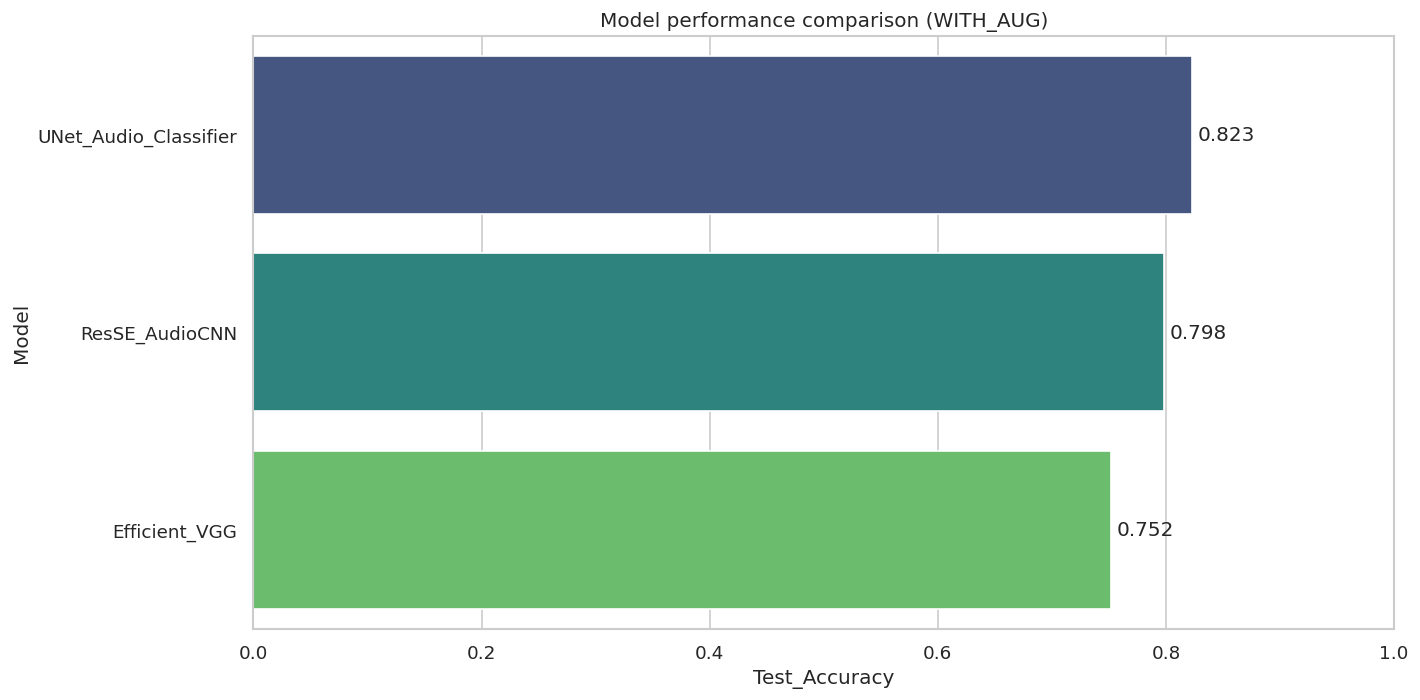

In [13]:
champion_df, champion_source, sort_col = None, None, None
for key in ['WITH_AUG', 'NO_AUG', 'INDIAN', 'TABLA', 'FMA']:
    df = dfs.get(key)
    if isinstance(df, pd.DataFrame):
        if ('Test_Accuracy' in df.columns) or ('Best_Val_Accuracy' in df.columns):
            champion_df = df.copy(); champion_source = key
            sort_col = 'Test_Accuracy' if 'Test_Accuracy' in df.columns else 'Best_Val_Accuracy'
            break

if champion_df is None:
    display(Markdown('_No summary found with expected columns. Please run the training notebooks._'))
else:
    leaderboard = champion_df.sort_values(sort_col, ascending=False).reset_index(drop=True)
    display(leaderboard)
    top = leaderboard.iloc[0]
    print(f"Champion: {top['Model']} (source: {champion_source})")
    if 'Test_Accuracy' in leaderboard.columns:
        print(f"Test Accuracy: {float(top.get('Test_Accuracy', np.nan)):.4f}")
    # Inline bar chart
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=leaderboard, x=sort_col, y='Model', orient='h', palette='viridis')
    for i, row in leaderboard.reset_index(drop=True).iterrows():
        ax.text(float(row[sort_col]) + 0.005, i, f"{float(row[sort_col]):.3f}", va='center')
    plt.title(f'Model performance comparison ({champion_source})')
    if sort_col.endswith('Accuracy'):
        plt.xlim(0, 1.0)
    plt.tight_layout(); plt.show()

## WP1 — SpecAugment Ablation (GTZAN)

Compare test accuracy with and without SpecAugment. Modest gains expected; large swings may indicate variance or instability.


,Model,Test_Accuracy_WITH,Test_Accuracy_NO,Gain_pp
2,UNet_Audio_Classifier,0.823,0.8180,0.500000
1,ResSE_AudioCNN,0.798,0.7990,-0.100005
0,Efficient_VGG,0.752,0.7535,-0.150001


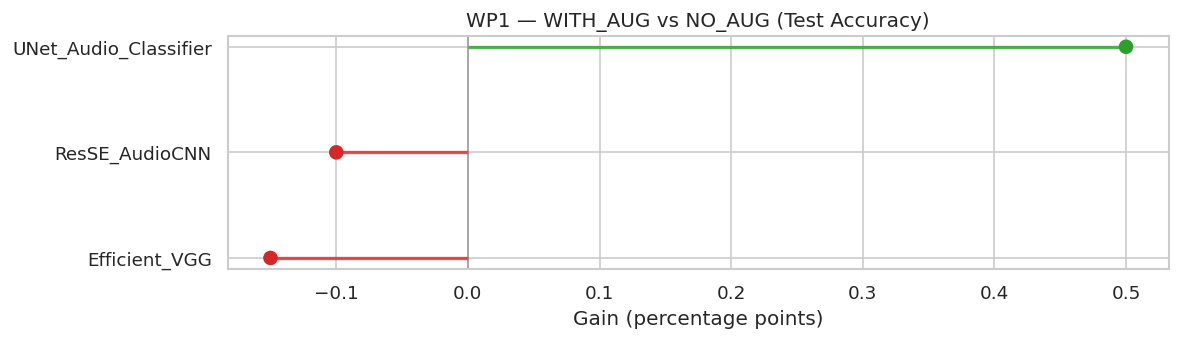

In [14]:
a, b = dfs.get('WITH_AUG'), dfs.get('NO_AUG')
if isinstance(a, pd.DataFrame) and isinstance(b, pd.DataFrame):
    cols = ['Model','Test_Accuracy']
    if all(c in a.columns for c in cols) and all(c in b.columns for c in cols):
        merged = (a[cols].merge(b[cols], on='Model', suffixes=('_WITH','_NO')))
        merged['Gain_pp'] = 100.0 * (merged['Test_Accuracy_WITH'] - merged['Test_Accuracy_NO'])
        display(merged.sort_values('Gain_pp', ascending=False))
        # Inline plot: lollipop
        m = merged.sort_values('Gain_pp')
        y = np.arange(len(m)); gains = m['Gain_pp'].to_numpy()
        colors = np.where(gains>=0, '#2ca02c', '#d62728')
        plt.figure(figsize=(10, max(3, 0.4*len(m))))
        plt.hlines(y, 0, gains, colors=colors, lw=2, alpha=0.8)
        plt.scatter(gains, y, c=colors, s=60)
        plt.axvline(0, color='gray', lw=1, alpha=0.6)
        plt.yticks(y, m['Model'])
        plt.xlabel('Gain (percentage points)'); plt.title('WP1 — WITH_AUG vs NO_AUG (Test Accuracy)')
        plt.tight_layout(); plt.show()
    else:
        print('WITH_AUG/NO_AUG summaries missing Test_Accuracy columns.')
else:
    print('WITH_AUG and/or NO_AUG summaries not available.')

## WP2 — Efficiency

Relate parameter count and single‑sample latency (batch=1) to test accuracy for WITH_AUG models.


,Model,Params,Latency_ms,Test_Accuracy
2,UNet_Audio_Classifier,1176170,23.066792,0.823
1,ResSE_AudioCNN,1232770,26.752510,0.798
0,Efficient_VGG,34488,14.771867,0.752


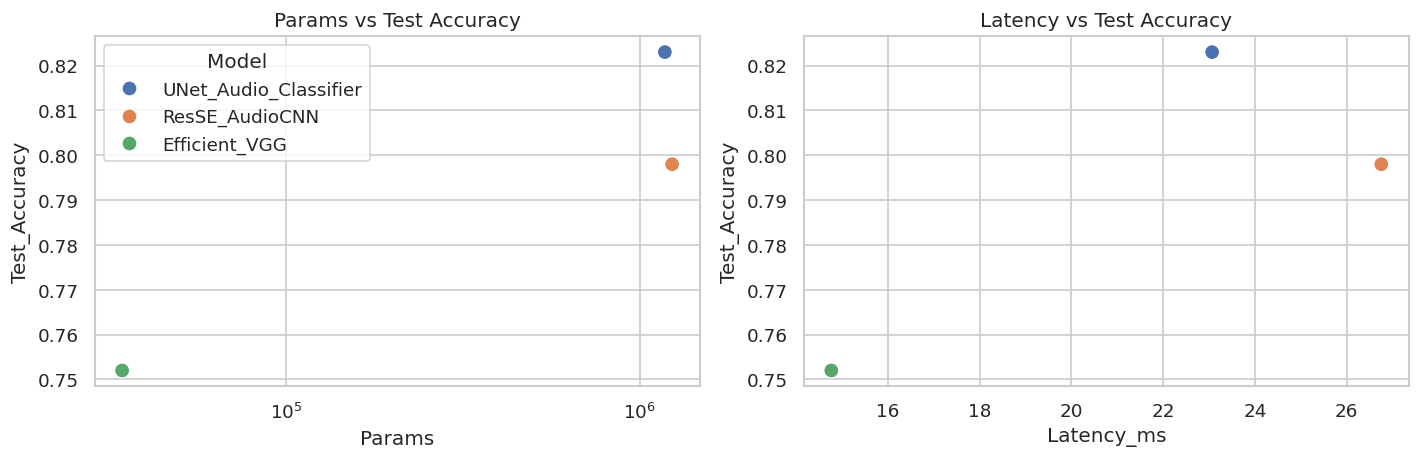

In [15]:
eff = dfs.get('WITH_AUG')
if isinstance(eff, pd.DataFrame) and all(c in eff.columns for c in ['Model','Params','Latency_ms','Test_Accuracy']):
    show = eff[['Model','Params','Latency_ms','Test_Accuracy']].sort_values('Test_Accuracy', ascending=False)
    display(show)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.scatterplot(ax=axes[0], data=show, x='Params', y='Test_Accuracy', hue='Model', s=80)
    axes[0].set_title('Params vs Test Accuracy'); axes[0].set_xscale('log')
    sns.scatterplot(ax=axes[1], data=show, x='Latency_ms', y='Test_Accuracy', hue='Model', s=80, legend=False)
    axes[1].set_title('Latency vs Test Accuracy')
    plt.tight_layout(); plt.show()
else:
    print('WITH_AUG summary missing required columns (Params, Latency_ms, Test_Accuracy).')

## Cross-Dataset (Top per Source)

Best model per source ranked by test (or fallback validation) accuracy.


,Source,Model,Score
7,TABLA,UNet_Audio_Classifier,0.964912
2,WITH_AUG,UNet_Audio_Classifier,0.823000
5,NO_AUG,UNet_Audio_Classifier,0.818000
6,INDIAN,UNet_Audio_Classifier,0.722000
8,FMA,UNet_Audio_Classifier,0.410937


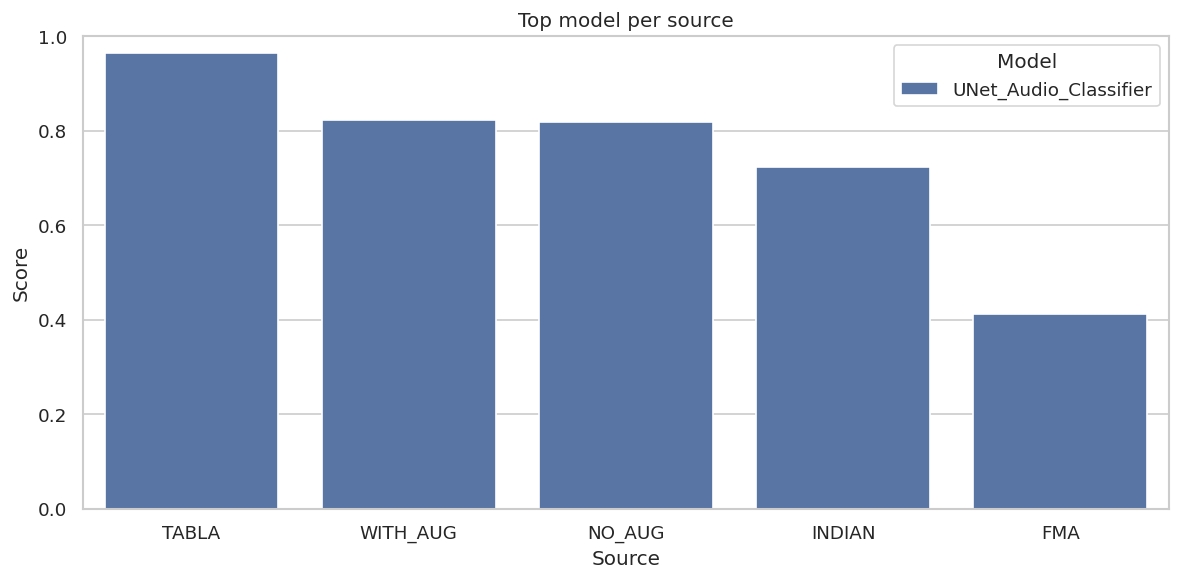

In [16]:
mdfs = []
for key in ['WITH_AUG','NO_AUG','INDIAN','TABLA','FMA']:
    df = dfs.get(key)
    if isinstance(df, pd.DataFrame):
        tmp = df.copy(); tmp['Source'] = key
        for c in ['Model','Test_Accuracy','Best_Val_Accuracy']:
            if c not in tmp.columns: tmp[c] = np.nan
        mdfs.append(tmp[['Source','Model','Test_Accuracy','Best_Val_Accuracy']])

if mdfs:
    combined = pd.concat(mdfs, ignore_index=True)
    combined['Score'] = combined['Test_Accuracy'].fillna(combined['Best_Val_Accuracy'])
    if combined['Score'].notna().any():
        top = combined.sort_values('Score', ascending=False).drop_duplicates('Source')
        display(top[['Source','Model','Score']])
        plt.figure(figsize=(10,5))
        sns.barplot(data=top.sort_values('Score', ascending=False), x='Source', y='Score', hue='Model')
        plt.ylim(0,1.0); plt.title('Top model per source'); plt.tight_layout(); plt.show()
    else:
        print('No valid scores to compare.')
else:
    print('No summaries available for cross-dataset comparison.')

## Test Metrics

For each dataset: parse classification report, compute macro and weighted summaries, plot per‑class F1, show confusion matrix, and ROC / PR curves if probabilities are available.


### GTZAN — Test metrics

,label,precision,recall,f1,support
0,blues,0.87,0.84,0.85,200
1,classical,0.96,1.00,0.98,200
2,country,0.75,0.80,0.78,200
3,disco,0.78,0.80,0.79,200
4,hiphop,0.77,0.74,0.76,200
5,jazz,0.89,0.96,0.93,200
6,metal,0.88,0.94,0.91,200
7,pop,0.76,0.89,0.82,200
8,reggae,0.91,0.69,0.79,200
9,rock,0.66,0.57,0.61,200


**Macro/Weighted summary**

,precision,recall,f1
macro,0.823,0.823,0.822
weighted,0.823,0.823,0.822


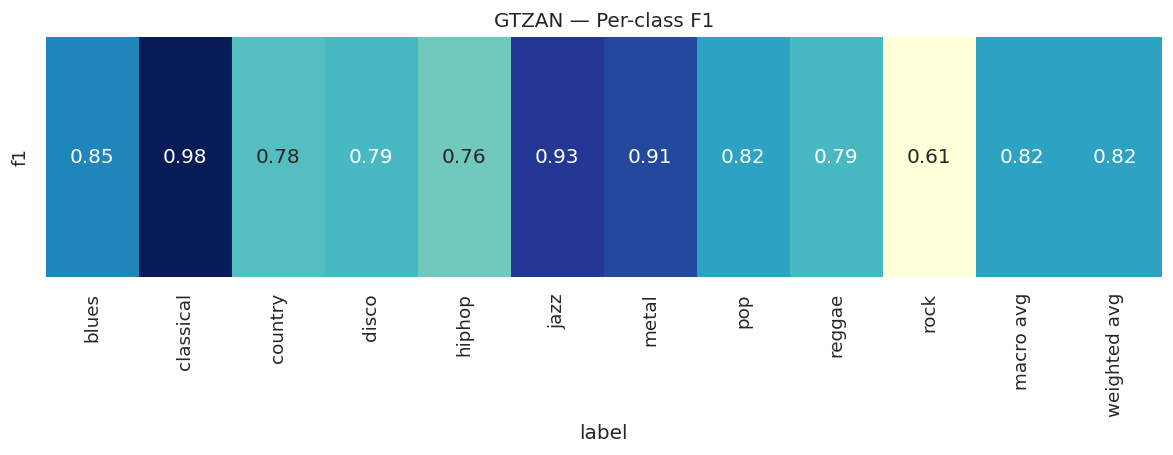

**Confusion matrix**

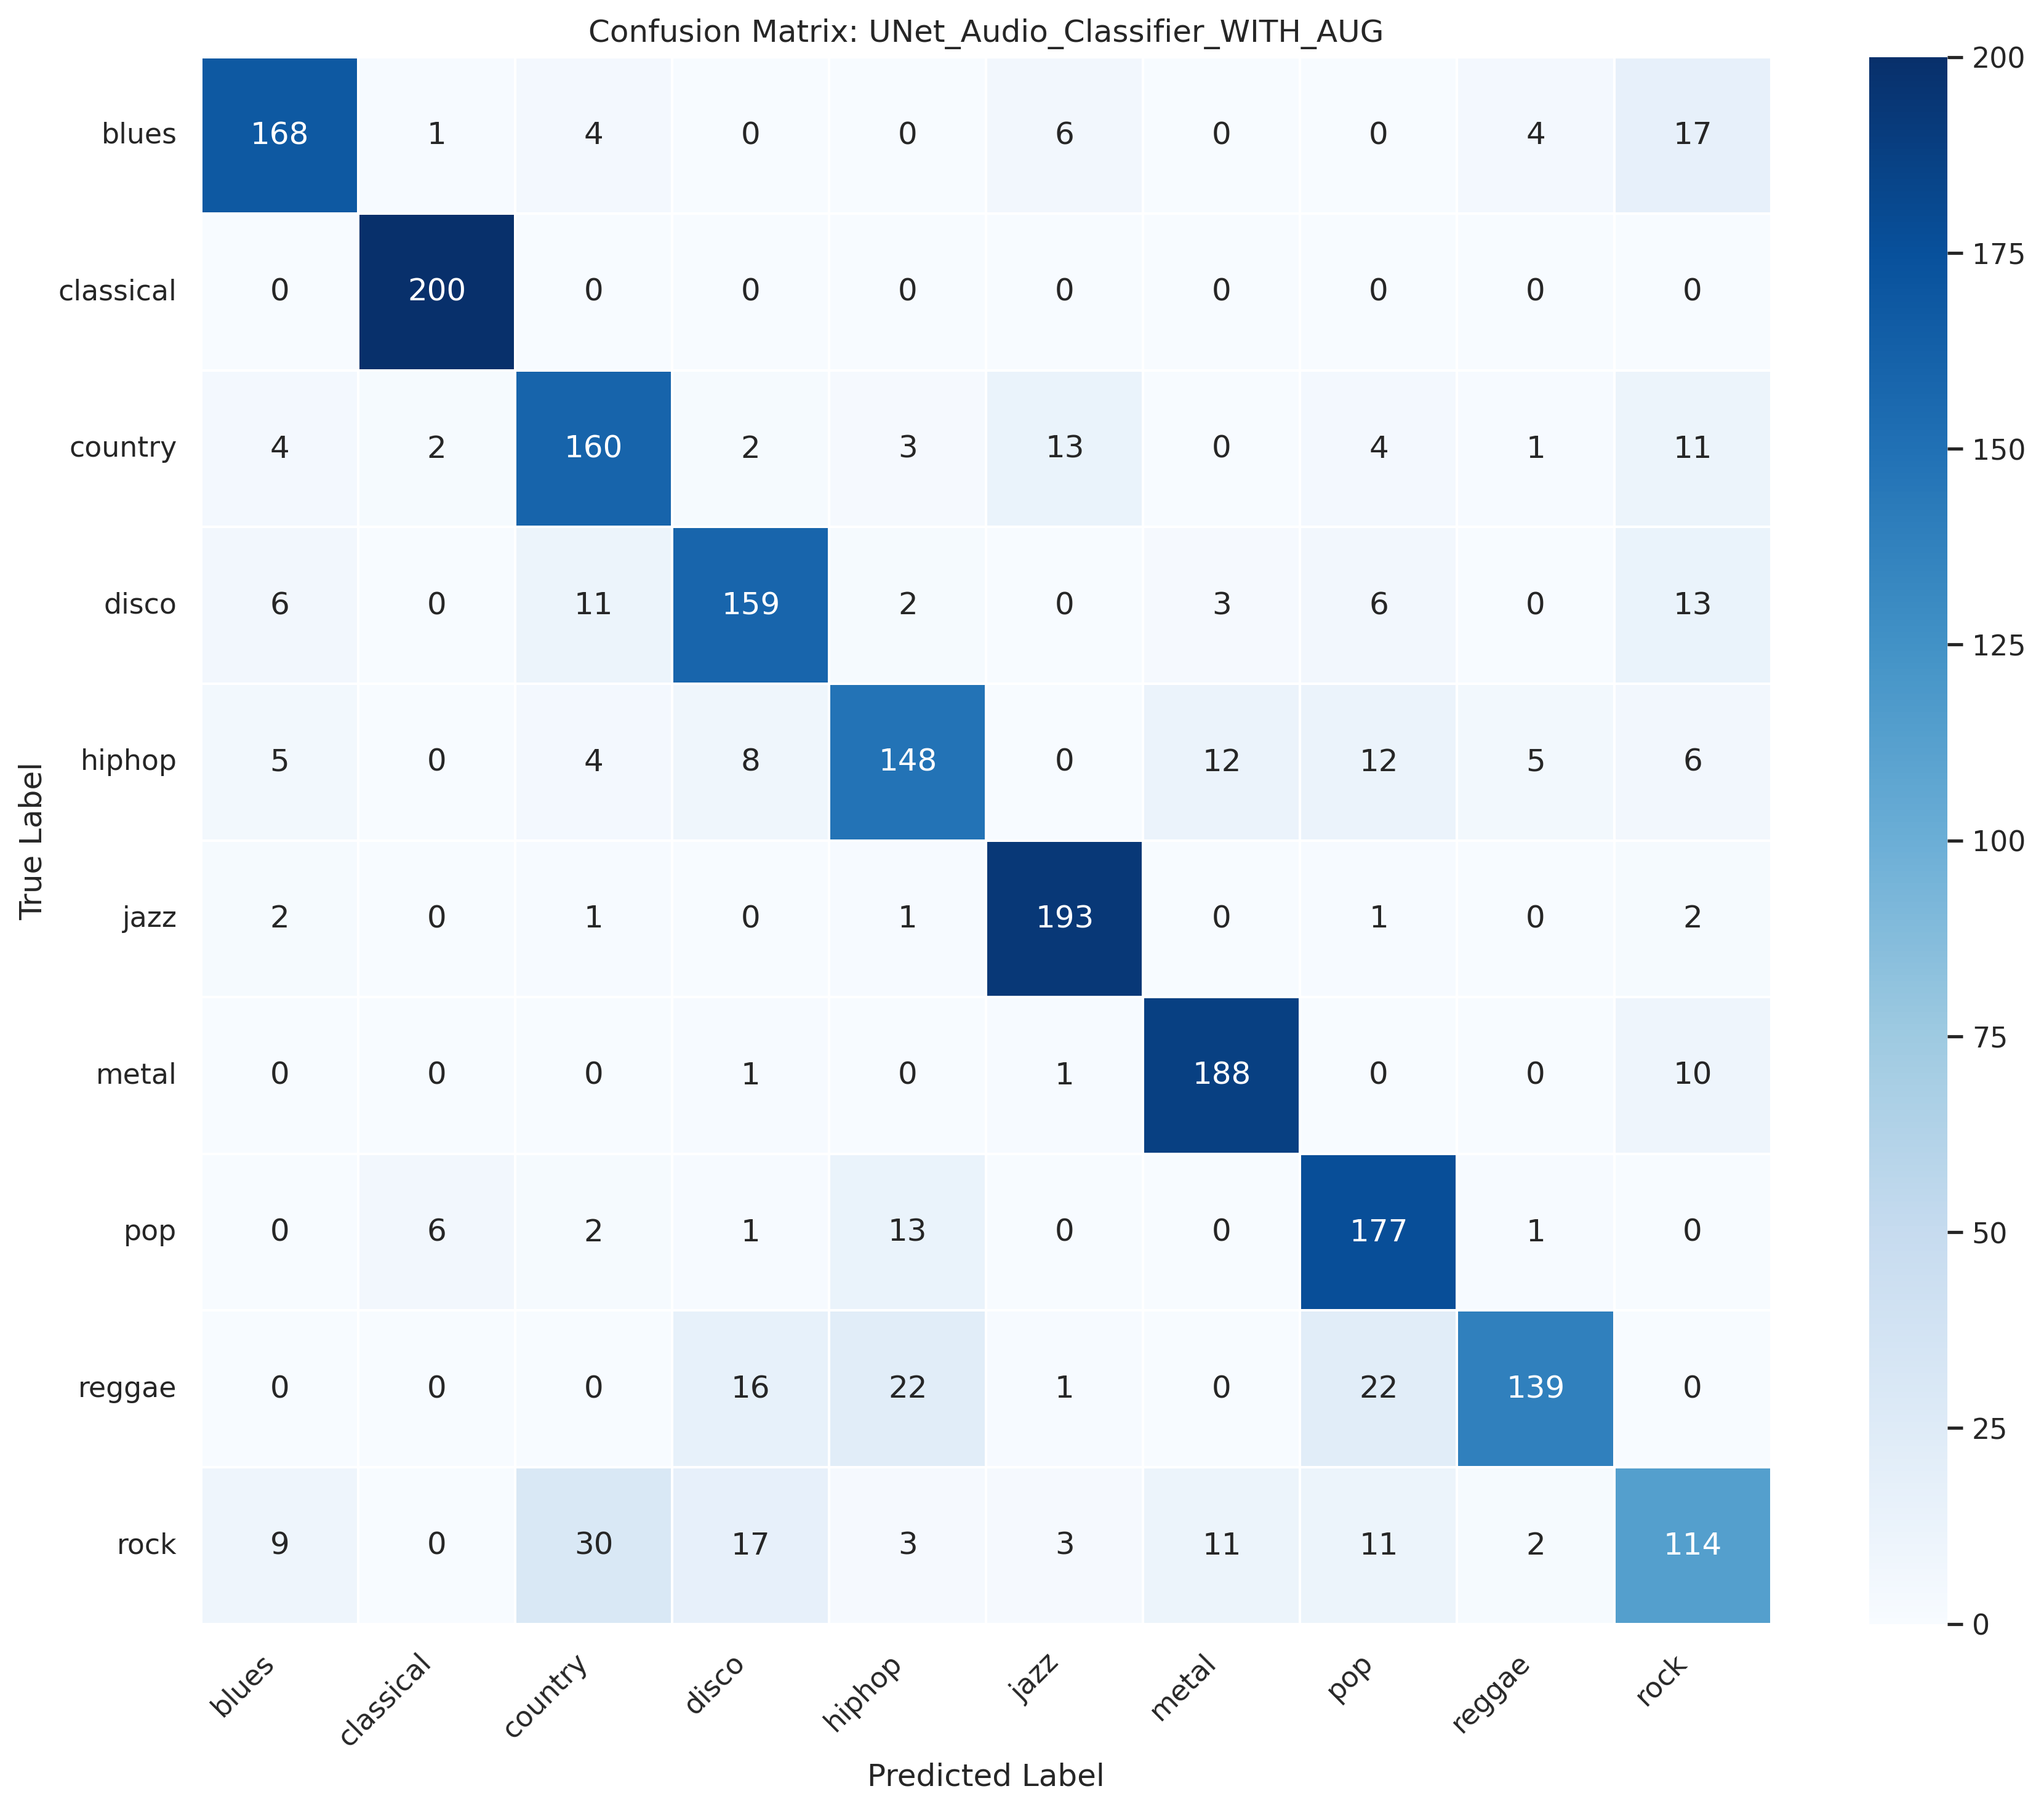

### FMA — Test metrics

,label,precision,recall,f1,support
0,Electronic,0.40,0.21,0.28,80
1,Experimental,0.46,0.54,0.49,80
2,Folk,0.33,0.51,0.40,80
3,Hip-Hop,0.47,0.54,0.50,80
4,Instrumental,0.48,0.51,0.50,80
5,International,0.45,0.31,0.37,80
6,Pop,0.03,0.03,0.03,80
7,Rock,0.61,0.64,0.63,80
8,macro avg,0.40,0.41,0.40,640
9,weighted avg,0.40,0.41,0.40,640


**Macro/Weighted summary**

,precision,recall,f1
macro,0.40375,0.41125,0.4
weighted,0.40375,0.41125,0.4


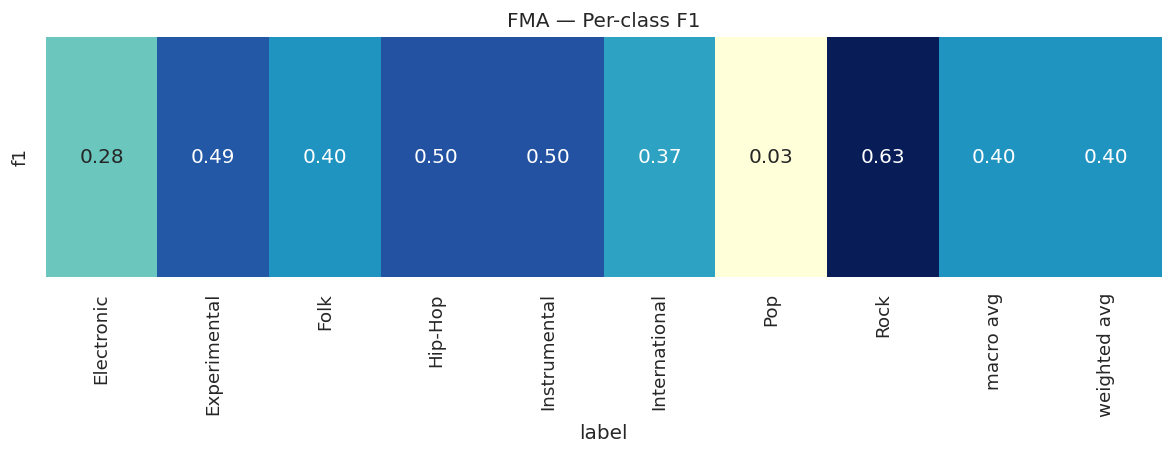

**Confusion matrix**

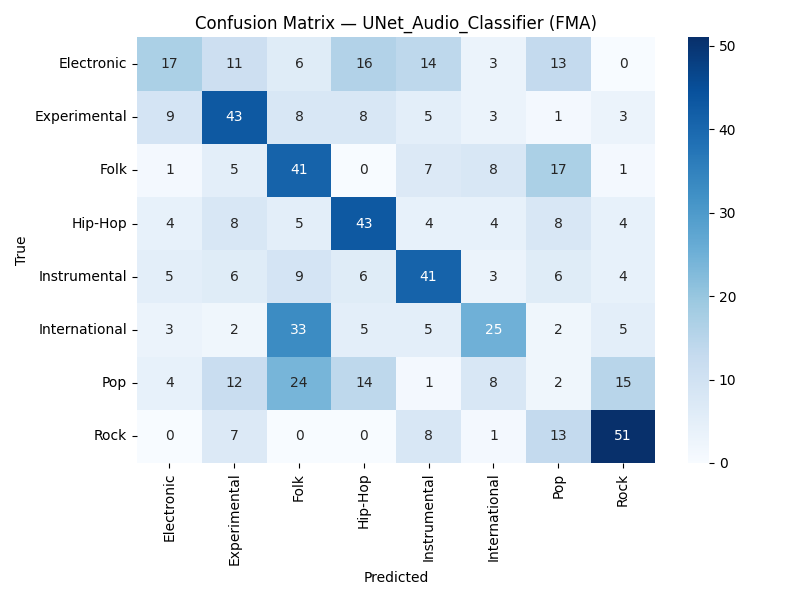

### INDIAN — Test metrics

,label,precision,recall,f1,support
0,bollypop,0.64,0.81,0.71,200
1,carnatic,0.86,0.83,0.84,200
2,ghazal,0.94,0.88,0.91,200
3,semiclassical,0.54,0.51,0.52,200
4,sufi,0.67,0.57,0.62,200
5,macro avg,0.73,0.72,0.72,1000
6,weighted avg,0.73,0.72,0.72,1000


**Macro/Weighted summary**

,precision,recall,f1
macro,0.73,0.72,0.72
weighted,0.73,0.72,0.72


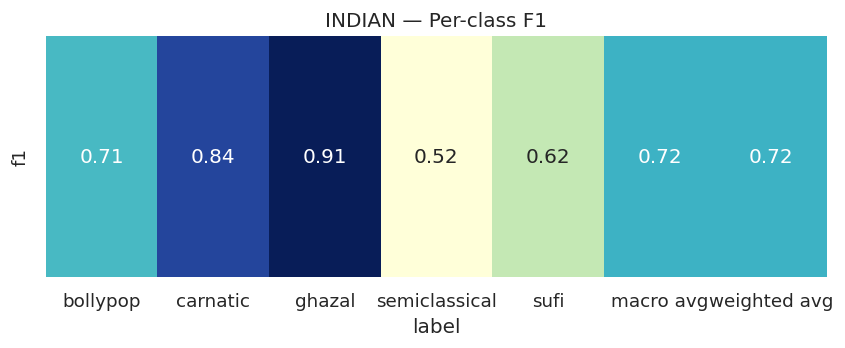

**Confusion matrix**

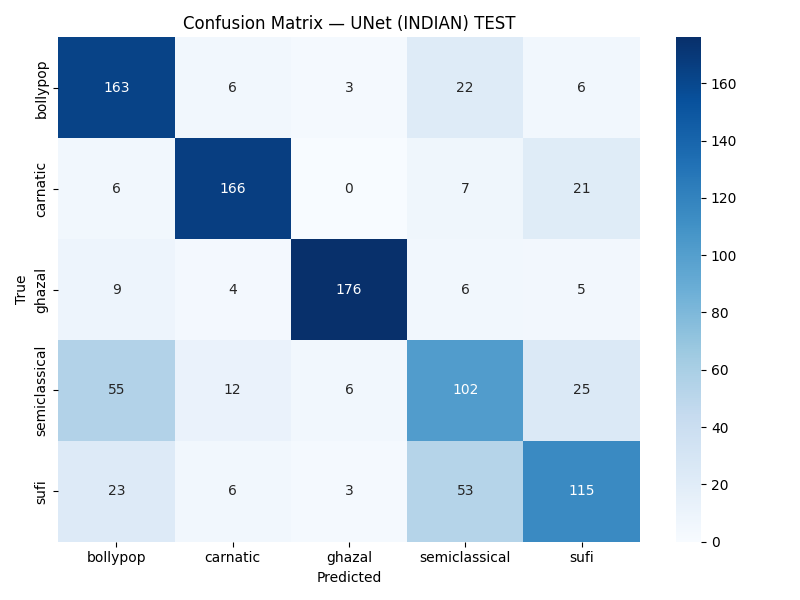

### TABLA — Test metrics

,label,precision,recall,f1,support
0,Addhatrital,1.0000,1.0000,1.0000,8
1,Bhajani,1.0000,1.0000,1.0000,8
2,Dadra,1.0000,1.0000,1.0000,7
3,Deepchandi,1.0000,0.8333,0.9091,6
4,Ektal,0.7500,1.0000,0.8571,6
5,Jhaptal,1.0000,0.8333,0.9091,6
6,Rupak,1.0000,1.0000,1.0000,6
7,Trital,1.0000,1.0000,1.0000,10
8,macro avg,0.9688,0.9583,0.9594,57
9,weighted avg,0.9737,0.9649,0.9658,57


**Macro/Weighted summary**

,precision,recall,f1
macro,0.968750,0.958325,0.959413
weighted,0.973684,0.964905,0.965821


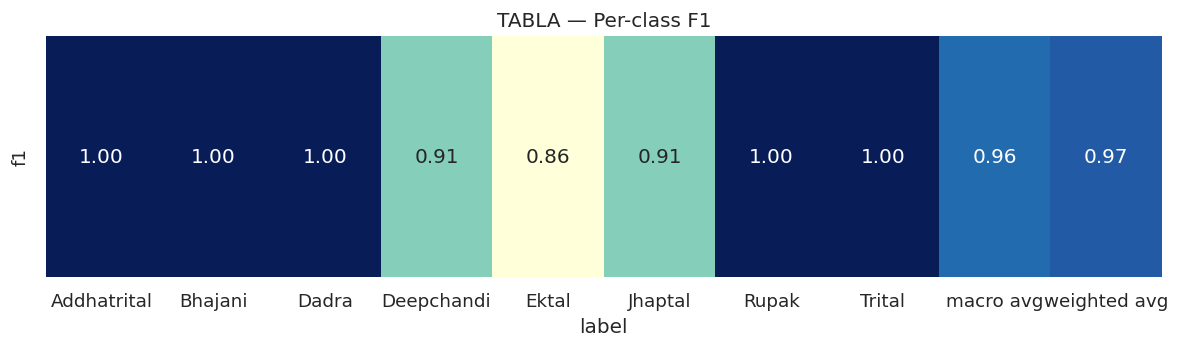

**Confusion matrix**

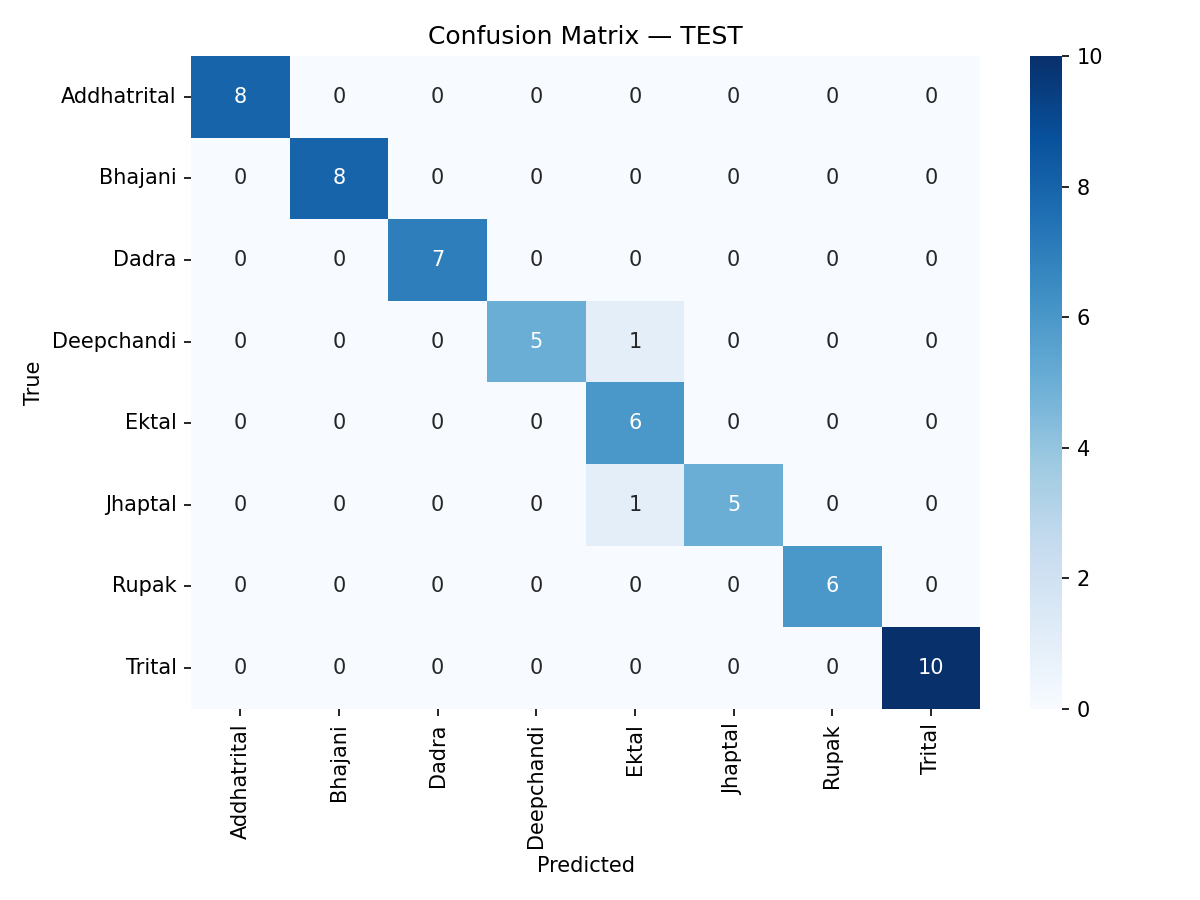

### Macro/Weighted F1 — cross-dataset

,Dataset,macro_f1,weighted_f1
0,GTZAN,0.822000,0.822000
1,FMA,0.400000,0.400000
2,INDIAN,0.720000,0.720000
3,TABLA,0.959413,0.965821


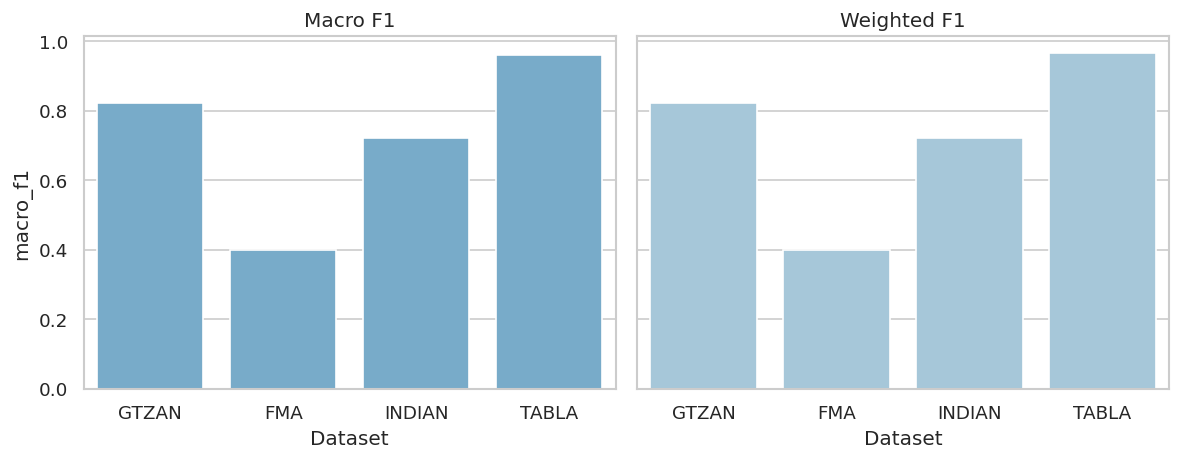

In [17]:
import re
_row_re = re.compile(r'^([^\s].*?)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9]+)\s*$')

DATASETS = {
    'GTZAN': {
        'report_files': ['classification_report_UNet_Audio_Classifier_WITH_AUG.txt',
                          'classification_report_UNet_Audio_Classifier.txt'],
        'cm_files': ['confusion_matrix_UNet_Audio_Classifier_WITH_AUG.png',
                       'confusion_matrix_UNet_Audio_Classifier.png'],
        'probs_files': ['probs_UNet_Audio_Classifier_WITH_AUG.npz',
                        'probs_UNet_Audio_Classifier.npz']
    },
    'FMA': {
        'report_files': ['classification_report_UNet_Audio_Classifier_FMA.txt'],
        'cm_files': ['confusion_matrix_UNet_Audio_Classifier_FMA.png'],
        'probs_files': ['probs_UNet_Audio_Classifier_FMA.npz']
    },
    'INDIAN': {
        'report_files': ['classification_report_UNet_Audio_Classifier_INDIAN.txt'],
        'cm_files': ['confusion_matrix_UNet_Audio_Classifier_INDIAN.png'],
        'probs_files': ['probs_UNet_Audio_Classifier_INDIAN.npz']
    },
    'TABLA': {
        'report_files': ['classification_report_UNet_Audio_Classifier_TABLA_TEST.txt'],
        'cm_files': ['confusion_matrix_UNet_Audio_Classifier_TABLA_TEST.png'],
        'probs_files': ['probs_AudioCNN_TABLA_TEST.npz']
    },
}

def parse_report_text(text: str) -> pd.DataFrame:
    rows = []
    for line in text.splitlines():
        m = _row_re.match(line.strip())
        if m:
            lbl, p, r, f1, sup = m.groups()
            rows.append({'label': lbl, 'precision': float(p), 'recall': float(r), 'f1': float(f1), 'support': int(sup)})
    return pd.DataFrame(rows)

def compute_macro_weighted(df: pd.DataFrame) -> pd.DataFrame:
    base = df[~df['label'].isin(['accuracy','macro avg','weighted avg'])].copy()
    if base.empty: return pd.DataFrame()
    macro = base[['precision','recall','f1']].mean().to_frame('macro').T
    weighted = pd.DataFrame({
        'precision': np.average(base['precision'], weights=base['support']),
        'recall': np.average(base['recall'], weights=base['support']),
        'f1': np.average(base['f1'], weights=base['support'])
    }, index=['weighted'])
    return pd.concat([macro, weighted])

def maybe_load_probs(names: List[str]) -> Optional[Dict[str, np.ndarray]]:
    for n in names:
        p = REPORTS / n
        if p.exists():
            try:
                data = np.load(p)
                if 'y_true' in data and 'y_prob' in data:
                    return {'y_true': data['y_true'], 'y_prob': data['y_prob']}
            except Exception as e:
                print('Failed to load', p, '->', e)
    return None

def plot_roc_pr(y_true: np.ndarray, y_prob: np.ndarray, class_names: Optional[List[str]] = None):
    C = y_prob.shape[1]
    y_true_bin = np.eye(C)[y_true]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # ROC
    for c in range(C):
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_prob[:, c])
        axes[0].plot(fpr, tpr, label=(class_names[c] if class_names else f'C{c}'))
    axes[0].plot([0,1],[0,1],'k--',alpha=0.5); axes[0].set_title('ROC (OvR)'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8, ncol=2)
    # PR
    for c in range(C):
        prec, rec, _ = precision_recall_curve(y_true_bin[:, c], y_prob[:, c])
        ap = average_precision_score(y_true_bin[:, c], y_prob[:, c])
        axes[1].plot(rec, prec, label=((class_names[c] if class_names else f'C{c}')+f' (AP={ap:.2f})'))
    axes[1].set_title('Precision–Recall (OvR)'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=8, ncol=2)
    fig.tight_layout(); plt.show()

all_cmp = []
for dset, spec in DATASETS.items():
    display(Markdown(f'### {dset} — Test metrics'))
    # Classification report
    rpt = next((REPORTS / f for f in spec['report_files'] if (REPORTS / f).exists()), None)
    if rpt is not None:
        txt = rpt.read_text()
        df = parse_report_text(txt)
        if not df.empty:
            display(df)
            summ = compute_macro_weighted(df)
            if not summ.empty:
                display(Markdown('**Macro/Weighted summary**'))
                display(summ)
                all_cmp.append({'Dataset': dset,
                                 'macro_f1': float(summ.loc['macro','f1']) if 'macro' in summ.index else np.nan,
                                 'weighted_f1': float(summ.loc['weighted','f1']) if 'weighted' in summ.index else np.nan})
            # Per-class F1 heatmap
            fig, ax = plt.subplots(figsize=(min(12, 1.2*len(df)), 2.6))
            f1df = df[['label','f1']].set_index('label').T
            sns.heatmap(f1df, annot=True, fmt='.2f', cmap='YlGnBu', cbar=False, ax=ax)
            ax.set_title(f'{dset} — Per-class F1'); plt.show()
        else:
            print('Could not parse the classification report; raw text follows:')
            print(txt)
    else:
        print('Classification report not found.')
    # Confusion matrix image
    cm = next((REPORTS / f for f in spec['cm_files'] if (REPORTS / f).exists()), None)
    if cm is not None:
        display(Markdown('**Confusion matrix**'))
        display(Image(filename=str(cm)))
    else:
        print('Confusion matrix not found.')
    # ROC/PR from probabilities if available
    probs = maybe_load_probs(spec['probs_files'])
    if probs is not None:
        plot_roc_pr(probs['y_true'], probs['y_prob'])

# Cross-dataset macro/weighted comparison
if all_cmp:
    comp = pd.DataFrame(all_cmp)
    display(Markdown('### Macro/Weighted F1 — cross-dataset'))
    display(comp)
    fig, ax = plt.subplots(1, 2, figsize=(10,4), sharey=True)
    sns.barplot(data=comp, x='Dataset', y='macro_f1', ax=ax[0], color='#6baed6'); ax[0].set_title('Macro F1')
    sns.barplot(data=comp, x='Dataset', y='weighted_f1', ax=ax[1], color='#9ecae1'); ax[1].set_title('Weighted F1')
    fig.tight_layout(); plt.show()
else:
    display(Markdown('_No dataset summaries available._'))

## WP4 — UNet 5-Fold CV (GTZAN)

Show mean ± std summary and per‑fold dispersion (violin + box).


**Mean ± Std (UNet 5-fold on GTZAN)**

,Model,Dataset,K,ValAcc_Mean,ValAcc_Std
0,UNet_Audio_Classifier,GTZAN,5,0.904375,0.006835


**Per-fold metrics**

,Fold,Val_Accuracy,Time_s
0,1,0.900625,152.923059
1,2,0.894375,145.697510
2,3,0.914375,147.913864
3,4,0.903750,174.203336
4,5,0.908750,122.072955


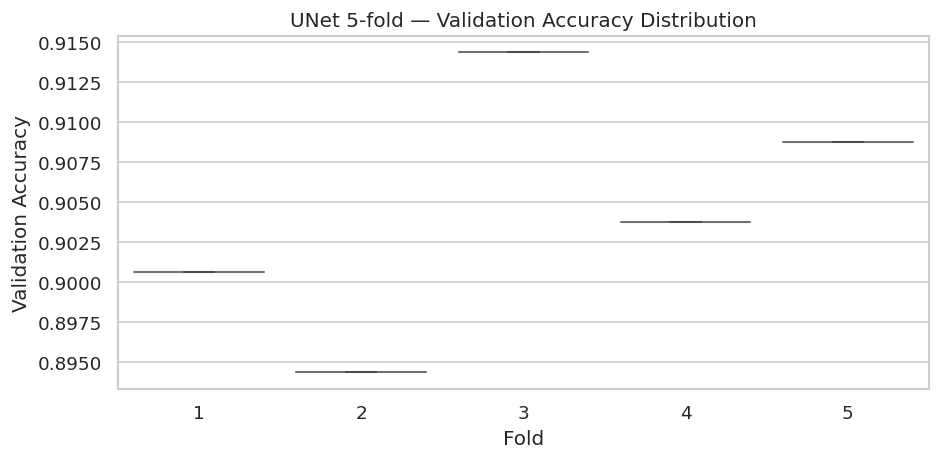

In [18]:
folds = dfs.get('CV_FOLDS'); summary = dfs.get('CV_SUM')
if isinstance(summary, pd.DataFrame):
    display(Markdown('**Mean ± Std (UNet 5-fold on GTZAN)**'))
    display(summary)
if isinstance(folds, pd.DataFrame):
    display(Markdown('**Per-fold metrics**'))
    display(folds)
    # Try to detect validation accuracy column
    cand = [c for c in ['Val_Accuracy','val_accuracy','Validation_Accuracy','Accuracy','val_acc'] if c in folds.columns]
    if cand:
        col = cand[0]
        fig, ax = plt.subplots(figsize=(8,4))
        sns.violinplot(data=folds, x='Fold', y=col, inner=None, color='#9ecae1', ax=ax)
        sns.boxplot(data=folds, x='Fold', y=col, width=0.2, showcaps=True, boxprops={'facecolor':'white'}, showfliers=False, ax=ax)
        ax.set_ylabel('Validation Accuracy'); ax.set_title('UNet 5-fold — Validation Accuracy Distribution')
        fig.tight_layout(); plt.show()
else:
    print('WP4 results not found. Please run notebooks/gtzan/01c_kfold_unet.ipynb')

## Appendix — Waveform & Mel Example (GTZAN)

One representative waveform and mel‑spectrogram per genre.


Loaded blues.00016.au using librosa.load (sr=22050)
Loaded classical.00059.au using librosa.load (sr=22050)


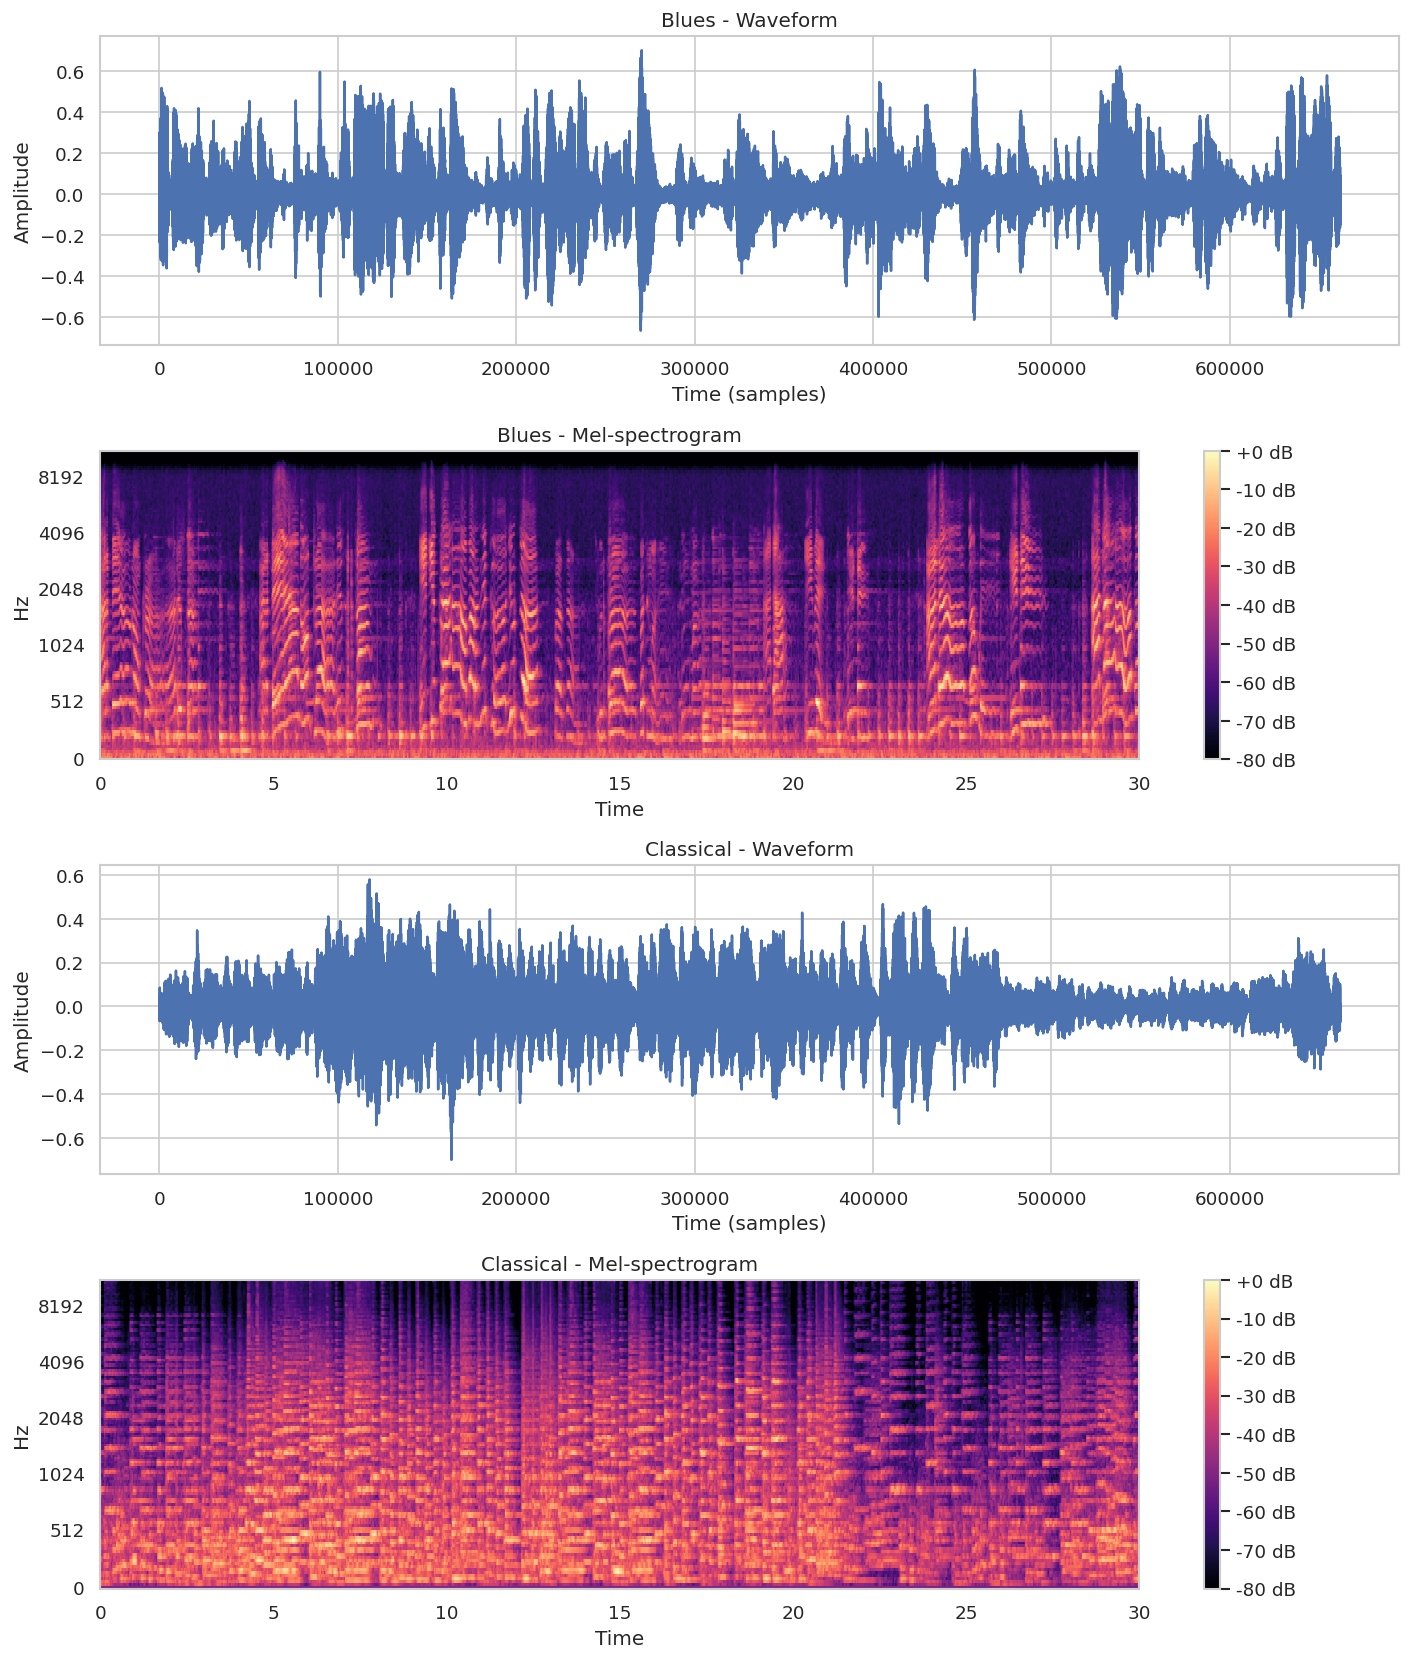

In [25]:
# Configuration - easily adjustable parameters
FIGSIZE = (12, 14)  # Figure size: (width, height) in inches
N_MELS = 128  # Number of mel bins for spectrogram
SR_TARGET = 22050  # Target sample rate for audio loading

fig, axes = plt.subplots(2 * len(genres), 1, figsize=FIGSIZE)
for i, genre in enumerate(genres):
    audio_files = find_genre_audio(genre, data_dir)
    if not audio_files:
        print(f"No audio files found for {genre}")
        continue
    file_path = audio_files[0]
    try:
        y, sr = load_audio_with_fallback(file_path)
        # Waveform
        axes[2*i].plot(y)
        axes[2*i].set_title(f'{genre.capitalize()} - Waveform')
        axes[2*i].set_xlabel('Time (samples)')
        axes[2*i].set_ylabel('Amplitude')
        # Mel-spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[2*i + 1])
        axes[2*i + 1].set_title(f'{genre.capitalize()} - Mel-spectrogram')
        fig.colorbar(img, ax=axes[2*i + 1], format='%+2.0f dB')
    except Exception as e:
        print(f"Error processing {genre}: {e}")

plt.tight_layout()
plt.show()